In [9]:
import sys; sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
import joblib
from sklearn.metrics import roc_auc_score

df = pd.read_csv("../data/processed/credit_default_features.csv")
y = df["default"]
X = df.drop(columns=["default"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

logreg_pipe = joblib.load("../src/logreg_model.joblib")
lgbm = joblib.load("../src/lgbm_model.joblib")

proba_logreg = logreg_pipe.predict_proba(X_test)[:, 1]
proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

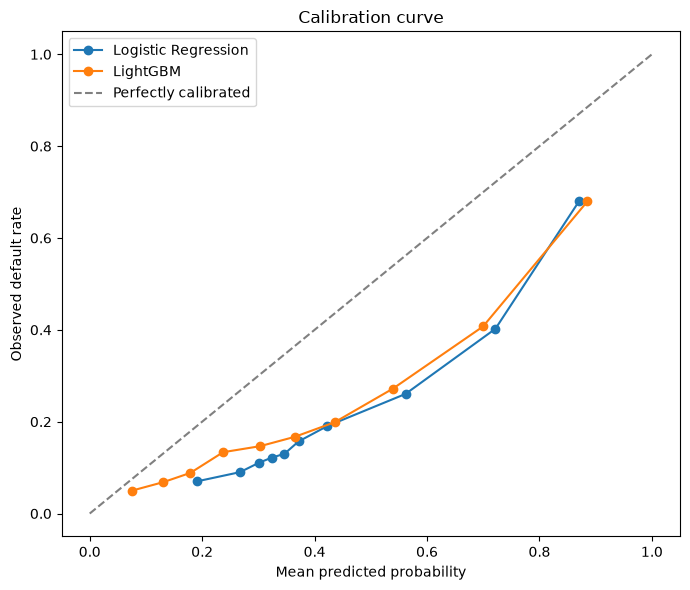

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

for proba, label in [(proba_logreg, "Logistic Regression"), (proba_lgbm, "LightGBM")]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=label)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed default rate")
ax.set_title("Calibration curve")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/calibration_curve.png", dpi=150)
plt.show()

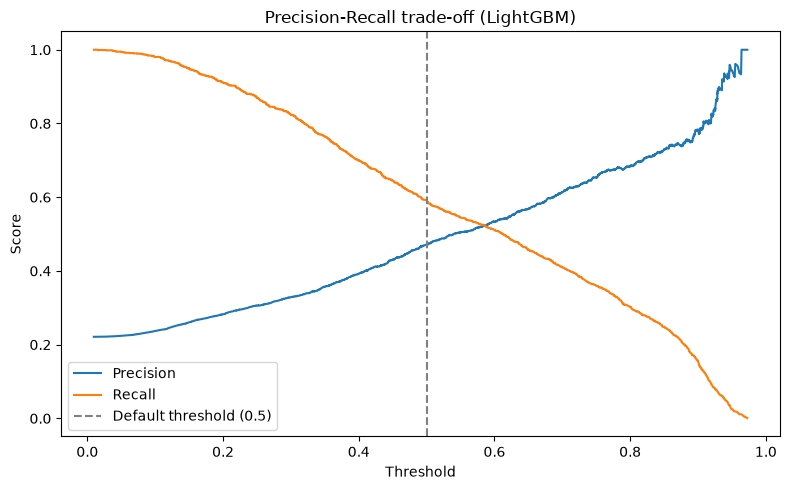

In [11]:
precision, recall, thresholds = precision_recall_curve(y_test, proba_lgbm)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.axvline(0.5, color="gray", linestyle="--", label="Default threshold (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall trade-off (LightGBM)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/precision_recall_tradeoff.png", dpi=150)
plt.show()

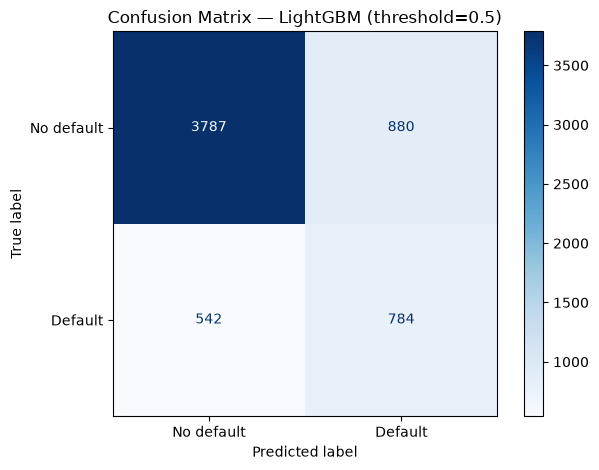

[[3787  880]
 [ 542  784]]


In [12]:
cm = confusion_matrix(y_test, lgbm.predict(X_test))
disp = ConfusionMatrixDisplay(cm, display_labels=["No default", "Default"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — LightGBM (threshold=0.5)")
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix.png", dpi=150)
plt.show()

print(cm)

In [13]:
import sklearn
print(sklearn.__version__)

1.9.1


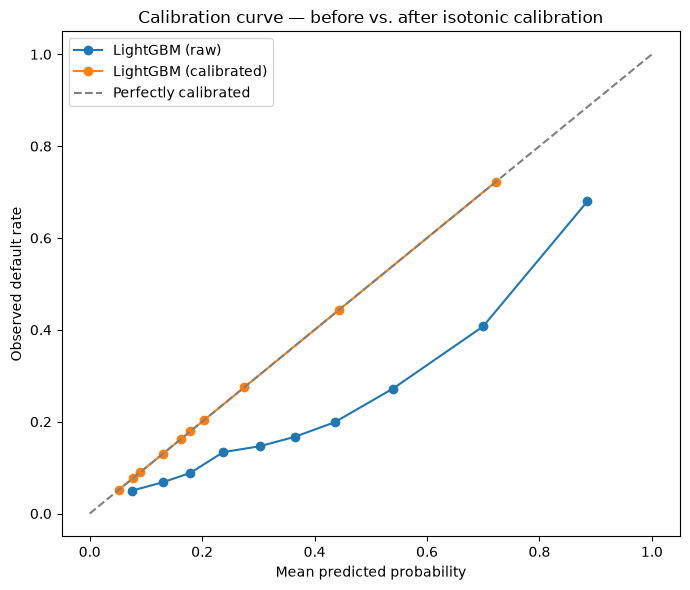

ROC-AUC (calibrated): 0.7748


In [14]:
from sklearn.calibration import CalibratedClassifierCV

try:
    # scikit-learn >= 1.6: wrap the already-fitted model with FrozenEstimator
    from sklearn.frozen import FrozenEstimator
    lgbm_calibrated = CalibratedClassifierCV(FrozenEstimator(lgbm), method="isotonic")
except ImportError:
    # scikit-learn < 1.6: old API
    lgbm_calibrated = CalibratedClassifierCV(lgbm, method="isotonic", cv="prefit")

lgbm_calibrated.fit(X_test, y_test)
proba_lgbm_cal = lgbm_calibrated.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
for proba, label in [(proba_lgbm, "LightGBM (raw)"),
                      (proba_lgbm_cal, "LightGBM (calibrated)")]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=label)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed default rate")
ax.set_title("Calibration curve — before vs. after isotonic calibration")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/calibration_curve_fixed.png", dpi=150)
plt.show()

print("ROC-AUC (calibrated):", round(roc_auc_score(y_test, proba_lgbm_cal), 4))